In [1]:
from bs4 import BeautifulSoup
import copy
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
from PIL import Image

In [2]:
edition_directory = "./KuiSCIMA/optical_symbolic_dataset/05_shanghai_manuscript/"
STANZA_SEPARATOR = '<space quantity="1" unit="chars"/>'

In [3]:
def boxes_to_coordinates(boxes, key: str):
    x_min = np.inf
    x_max = 0
    y_min = np.inf
    y_max = 0
    
    for box in boxes:
        (x1, y1), (x2, y2) = box[key]
        x_min = min(x1, x2, x_min)
        x_max = max(x1, x2, x_max)
        y_min = min(y1, y2, y_min)
        y_max = max(y1, y2, y_max)

    return ((x_min, y_min), (x_max, y_max))

def add_pb_and_lb(box):
    tei_string = ""
    if "tei_pb" in box:
        tei_string += f'<pb facs="#{box["tei_pb"]}"/>'
    if "tei_lb" in box:
        tei_string += f'<lb facs="#{box["tei_lb"]}"/>'
    return tei_string

In [4]:
class Line:
    def __init__(self, boxes: list):
        self.boxes = boxes

    def __len__(self):
        return len(self.boxes)

    def __iter__(self):
        return iter(self.boxes)

    def __getitem__(self, idx: int):
        return self.boxes[idx]

    def __delitem__(self, idx: int):
        del self.boxes[idx]

    def append(self, item):
        self.boxes.append(item)

        
class TextLine(Line):
    def __repr__(self):
        return f"TextLine({"".join([box["text_content"] for box in self.boxes])})"

    def coordinates(self):
        return boxes_to_coordinates(self.boxes, key="text_coordinates")

    def page(self):
        return self.boxes[0]["text_page"]
        

class LyricsLine(Line):
    def __repr__(self):
        return f"LyricsLine({"".join([box["text_content"] for box in self.boxes])})"

    def coordinates(self):
        return boxes_to_coordinates(self.boxes, key="text_coordinates")

    def page(self):
        return self.boxes[0]["text_page"]


class MusicLine(Line):
    def __repr__(self):
        return f"MusicLine({"".join(["*" for box in self.boxes])})"

    def coordinates(self):
        return boxes_to_coordinates(self.boxes, key="notation_coordinates")

    def page(self):
        return self.boxes[0]["notation_page"]


class IndependentMusicLine(Line):
    def __repr__(self):
        return f"IndependentMusicLine({"".join(["*" for box in self.boxes])})"

    def coordinates(self):
        return boxes_to_coordinates(self.boxes, key="notation_coordinates")

    def page(self):
        return self.boxes[0]["notation_page"]


class CombinedLine:
    def __init__(self, notation_boxes, lyrics_boxes):
        self.notation_boxes = notation_boxes
        self.lyrics_boxes = lyrics_boxes

    def __repr__(self):
        return f"CombinedLine({"".join(["*" for box in self.notation_boxes])}{"".join([box["text_content"] for box in self.lyrics_boxes])})"

In [5]:
def transform_coordinates(box, images):
    (x, y), (x2, y2) = box
    offset = 0
    for page_idx, page in enumerate(images[::-1]):  # pages are read from right to left
        offset += page.width
        if x < offset:
            break
    
    correct_page_idx = len(images)-1-page_idx
    x_offset = offset-page.width

    return correct_page_idx, ((x-x_offset, y), (x2-x_offset, y2))

def segment_boxes_into_lines(boxes: list, images: list[Image]):
    raw_lines = []
    for box in boxes:
        if "notation_coordinates" in box and box["notation_coordinates"] is not None:
            page_idx, new_box = transform_coordinates(box["notation_coordinates"], images)
            box["notation_coordinates"] = new_box
            box["notation_page"] = os.path.basename(images[page_idx].filename)
        if "text_coordinates" in box and box["text_coordinates"] is not None:
            page_idx, new_box = transform_coordinates(box["text_coordinates"], images)
            box["text_coordinates"] = new_box
            box["text_page"] = os.path.basename(images[page_idx].filename)
        if len(raw_lines) == 0 or raw_lines[-1][-1]["is_line_break"]:
            raw_lines.append([box])
        else:
            raw_lines[-1].append(box)
        

    lines = []
    for line in raw_lines:
        line_types = set([box["box_type"] for box in line])
        if len(line_types) == 1 and "Music" in line_types:
            if line[0]["notation_content"] is not None:
                lines.append(MusicLine(copy.deepcopy(line)))
            if line[0]["text_content"] is not None:
                lines.append(LyricsLine(line))
        elif "Music" not in line_types:
            lines.append(TextLine(line))
        else:
            print("WARNING:", line_types)
            print("".join([box["text_content"] for box in line]))
            print([image.filename for image in images])
            print()
            
    return lines


def segment_boxes_into_lines_guyuan(boxes: list, images: list[Image]):
    raw_lines = []
    for box in boxes:
        if "notation_coordinates" in box and box["notation_coordinates"] is not None:
            page_idx, new_box = transform_coordinates(box["notation_coordinates"], images)
            box["notation_coordinates"] = new_box
            box["notation_page"] = os.path.basename(images[page_idx].filename)
        if "text_coordinates" in box and box["text_coordinates"] is not None:
            page_idx, new_box = transform_coordinates(box["text_coordinates"], images)
            box["text_coordinates"] = new_box
            box["text_page"] = os.path.basename(images[page_idx].filename)
        if len(raw_lines) == 0 or raw_lines[-1][-1]["is_line_break"]:
            raw_lines.append([box])
        else:
            raw_lines[-1].append(box)

    lines = []
    for line in raw_lines:
        line_types = set([box["box_type"] for box in line])
        if len(line_types) == 1 and "Music" in line_types:
            if line[0]["notation_content"] is not None and len(set([box["text_content"] for box in line])) == 1:
                lines.append(IndependentMusicLine(copy.deepcopy(line)))
            else:
                if line[0]["notation_content"] is not None:
                    lines.append(MusicLine(copy.deepcopy(line)))
                if line[0]["text_content"] is not None:
                    lines.append(LyricsLine(line))
        elif "Music" not in line_types:
            lines.append(TextLine(line))
            
    return lines

def add_content_with_comment(box):
    tei_string = ""
    if "tei_start_comment" in box:
        tei_string += '<seg rend="small" type="note">'
    tei_string += box["text_content"]
    if "tei_end_comment" in box:
        tei_string += '</seg>'
    return tei_string

In [15]:
class JsonBased:
    def __init__(self, file_path: str):
        with open(file_path, "r") as file_handle:
            self.json = json.load(file_handle)
        self.boxes = self.json["content"]
        self.image_files = self.json["images"]
        self.file = os.path.basename(file_path)
        images = [Image.open(os.path.join(os.path.dirname(file_path), image_file)) for image_file in self.image_files]
        self.physical_lines = segment_boxes_into_lines(self.boxes, images)

class TextOnlySong(JsonBased):
    def __init__(self, *args, comment=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.title = "".join([box["text_content"] for box in self.boxes if box["box_type"] == "Title"])

        # Update logical lines
        self.logical_lines = [LyricsLine([])]
        for lyric_box in [box for line in self.physical_lines for box in line if isinstance(line, LyricsLine)]:
            if lyric_box["text_content"] in (None, "", " "):
                self.logical_lines.append(LyricsLine([]))
            else:
                self.logical_lines[-1].append(lyric_box)

        # Update boxes accordingly
        self.boxes = [box for line in self.physical_lines for box in line]

        # Mark the comment
        comment_found = False
        if comment is not None and len(comment) > 0:
            for box_idx in range(len(self.boxes) - len(comment) + 1):
                box_text = "".join([box["text_content"] for box in self.boxes[box_idx:box_idx+len(comment)]])
                if box_text == comment:
                    self.boxes[box_idx]["tei_start_comment"] = True
                    self.boxes[box_idx+len(comment)-1]["tei_end_comment"] = True
                    comment_found = True
                    break
            if not comment_found:
                print(f"WARNING! COMMENT {comment} WAS NOT FOUND")
            

    def __str__(self):
        return f"MilitarySong({self.title}, {self.file})"
    
    def to_tei(self):
        tei_string = ""

        # First, title
        title_line = self.physical_lines[0]
        tei_string += "<head><title>"
        tei_string += add_pb_and_lb(title_line[0])
        for box in title_line:
            if box["box_type"] == "Title":
                tei_string += add_content_with_comment(box)
        tei_string += "</title>"
        if "Mode" in [box["box_type"] for box in title_line]:
            tei_string += '<seg rend="small" type="mode">'
            for box in title_line:
                if box["box_type"] == "Mode":
                    tei_string += add_content_with_comment(box)
            tei_string += "</seg>"
        tei_string += "</head>"
        
        # Second, preface
        preface_lines = [line for line in self.physical_lines if "Preface" in [box["box_type"] for box in line]]
        if len(preface_lines):
            tei_string += '<p ana="description">'
            for line in preface_lines:
                for box in line:
                    if box["box_type"] == "Preface":
                        tei_string += add_pb_and_lb(box)
                        tei_string += add_content_with_comment(box)
            last_line = preface_lines[-1]
            if "Mode" in [box["box_type"] for box in last_line]:
                tei_string += '<seg rend="small" type="mode">'
                for box in last_line:
                    if box["box_type"] == "Mode":
                        tei_string += box["text_content"]
                tei_string += "</seg>"
            tei_string += "</p>"

        # Third, lyrics
        tei_string += "<lg>"
        for line in self.logical_lines:
            tei_string += "<l>"
            for box in line:
                tei_string += add_pb_and_lb(box)
                tei_string += add_content_with_comment(box)
            tei_string += f"</l>{STANZA_SEPARATOR}"  # add a stanza separator between each stanza
        tei_string = tei_string[:-len(STANZA_SEPARATOR)]  # remove the last stanza separator
        tei_string += "</lg>"

        return f'<div type="song" xml:id="song_{self.file.split(".")[0]}">{tei_string}</div>'


class BiejiSong(JsonBased):
    def __init__(self, file_path: str, switch_order: bool = False):
        with open(file_path, "r") as file_handle:
            self.json = json.load(file_handle)
        self.boxes = self.json["content"]
        self.image_files = self.json["images"]
        self.file = os.path.basename(file_path)
        images = [Image.open(os.path.join(os.path.dirname(file_path), image_file)) for image_file in self.image_files]

        # Update box order accordingly
        self.switch_order = switch_order
        
        if switch_order:
            text_boxes = [box for box in self.boxes if box["box_type"] != "Music"]
            music_boxes = [box for box in self.boxes if box["box_type"] == "Music"]
            self.boxes = music_boxes + text_boxes

        # Update physical lines
        self.physical_lines = segment_boxes_into_lines(self.boxes, images)

        # Update logical lines
        self.logical_lines = [LyricsLine([])]
        for lyric_box in [box for line in self.physical_lines for box in line if isinstance(line, LyricsLine)]:
            if lyric_box["text_content"] in (None, "", " "):
                self.logical_lines.append(LyricsLine([]))
            else:
                self.logical_lines[-1].append(lyric_box)
        
        # Update boxes accordingly
        self.boxes = [box for line in self.physical_lines for box in line]

    def __str__(self):
        return f"MilitarySong({self.title}, {self.file})"
    
    def to_tei(self):
        tei_string = ""

        if self.switch_order:
        # if the order is switched, we have lyrics before the preface.
        # In this case, we never have a title (pieces 095-101)
            tei_string += "<lg>"
            for line in self.logical_lines:
                tei_string += "<l>"
                for box in line:
                    tei_string += add_pb_and_lb(box)
                    tei_string += box["text_content"]
                tei_string += f"</l>{STANZA_SEPARATOR}"  # add a stanza separator between each stanza
            tei_string = tei_string[:-len(STANZA_SEPARATOR)]  # remove the last stanza separator
            tei_string += "</lg>"
            
            preface_lines = [line for line in self.physical_lines if "Preface" in [box["box_type"] for box in line]]
            if len(preface_lines):
                tei_string += '<p ana="description">'
                for line in preface_lines:
                    for box in line:
                        if box["box_type"] == "Preface":
                            tei_string += add_pb_and_lb(box)
                            tei_string += box["text_content"]
                tei_string += '</p>'
        else:
            # otherwise, we have two other cases:
            box_types = [box["box_type"] for box in self.boxes]
            try:
                preface_first = box_types.index("Preface") < box_types.index("Title")
            except ValueError:  # if no title box is found
                preface_first = False
                
            if preface_first:
                # 1) First preface, then title, then lyrics
                preface_boxes = [box for box in self.boxes if box["box_type"] == "Preface"]
                if len(preface_boxes):
                    tei_string += '<p ana="description">'
                    for box in preface_boxes:
                        tei_string += add_pb_and_lb(box)
                        tei_string += box["text_content"]
                        
                    title_boxes = [box for box in self.boxes if box["box_type"] == "Title"]
                    if len(title_boxes):
                        tei_string += '<title>'
                        for box in title_boxes:
                            tei_string += box["text_content"]
                        tei_string += '</title>'
                    tei_string += '</p>'

                tei_string += "<lg>"
                for line in self.logical_lines:
                    tei_string += "<l>"
                    for box in line:
                        tei_string += add_pb_and_lb(box)
                        tei_string += box["text_content"]
                    tei_string += f"</l>{STANZA_SEPARATOR}"  # add a stanza separator between each stanza
                tei_string = tei_string[:-len(STANZA_SEPARATOR)]  # remove the last stanza separator
                tei_string += "</lg>"
                        
            else:
                # 2) Optional title, then preface, then lyrics
                title_boxes = [box for box in self.boxes if box["box_type"] == "Title"]
                if len(title_boxes):
                    tei_string += '<head><title>'
                    for box in title_boxes:
                        tei_string += box["text_content"]
                    tei_string += '</title></head>'

                preface_boxes = [box for box in self.boxes if box["box_type"] == "Preface"]
                if len(preface_boxes):
                    tei_string += '<p ana="description">'
                    for box in preface_boxes:
                        tei_string += add_pb_and_lb(box)
                        tei_string += box["text_content"]
                    tei_string += '</p>'
                    
                tei_string += "<lg>"
                for line in self.logical_lines:
                    tei_string += "<l>"
                    for box in line:
                        tei_string += add_pb_and_lb(box)
                        tei_string += box["text_content"]
                    tei_string += "</l> "  # add a stanza separator between each stanza
                tei_string = tei_string[:-1]  # remove the last stanza separator
                tei_string += "</lg>"

        return f'<div type="song" xml:id="song_{self.file.split(".")[0]}">{tei_string}</div>'


class Song(JsonBased):
    def __init__(self, *args, comment=None, preface_small=False, **kwargs):
        super().__init__(*args, **kwargs)
        self.preface_small = preface_small
        self.title = "".join([box["text_content"] for box in self.boxes if box["box_type"] == "Title"])

        self.logical_lines = [[CombinedLine([], [])]]
        for notation_box, lyric_box in zip([box for line in self.physical_lines for box in line if isinstance(line, LyricsLine)], [box for line in self.physical_lines for box in line if isinstance(line, MusicLine)]):
            if lyric_box["text_content"] in (None, "", " "):
                self.logical_lines.append([CombinedLine([], [])])
            elif lyric_box["is_line_break"]:
                self.logical_lines[-1][-1].notation_boxes.append(notation_box)
                self.logical_lines[-1][-1].lyrics_boxes.append(lyric_box)
                self.logical_lines[-1] += [CombinedLine([], [])]
            else:
                self.logical_lines[-1][-1].notation_boxes.append(notation_box)
                self.logical_lines[-1][-1].lyrics_boxes.append(lyric_box)
        del self.logical_lines[-1][-1]

        # There are additional logical line break boxes that should be removed
        for line in self.physical_lines:
            if line[-1]["text_content"] in (None, "", " "):
                del line[-1]

        # Update boxes accordingly
        self.boxes = [box for line in self.physical_lines for box in line]

        # Mark the comment
        comment_found = False
        if comment is not None and len(comment) > 0:
            for box_idx in range(len(self.boxes) - len(comment) + 1):
                box_text = "".join([box["text_content"] for box in self.boxes[box_idx:box_idx+len(comment)]])
                if box_text == comment:
                    self.boxes[box_idx]["tei_start_comment"] = True
                    self.boxes[box_idx+len(comment)-1]["tei_end_comment"] = True
                    comment_found = True
                    break
            if not comment_found:
                print(f"WARNING! COMMENT {comment} WAS NOT FOUND")

    def __str__(self):
        return f"Song({self.title}, {self.file})"
    
    def to_tei(self):
        tei_string = ""

        title_or_mode_line = self.physical_lines[0]
        tei_string += '<head><title>'
        
        for box in title_or_mode_line:
            if box["box_type"] == "Title":
                tei_string += add_content_with_comment(box)
        tei_string += '</title>'

        mode_boxes = [box for box in title_or_mode_line if box["box_type"] == "Mode"]
        if len(mode_boxes):
            tei_string += '<seg rend="small" type="mode">'
            for box in mode_boxes:
                tei_string += add_content_with_comment(box)
            tei_string += "</seg>"
        
        tei_string += '</head>'

        preface_or_mode_lines = [line for line in self.physical_lines if line[0]["box_type"] == "Preface"]
        preface_boxes = [box for box in self.boxes if box["box_type"] == "Preface"]
        mode_boxes = [box for line in preface_or_mode_lines for box in line if box["box_type"] == "Mode"]
        if len(preface_boxes):
            if self.preface_small:
                tei_string += '<p rend="small" ana="description">'
            else:
                tei_string += '<p ana="description">'
            for box in preface_boxes:
                tei_string += add_pb_and_lb(box)
                tei_string += add_content_with_comment(box)
            if len(mode_boxes):
                tei_string += '<seg rend="small" type="mode">'
                for box in mode_boxes:
                    tei_string += add_content_with_comment(box)
                tei_string += "</seg>"
            tei_string += '</p>'

        tei_string += "<lg>"
        for line in self.logical_lines:
            tei_string += "<l>"
            for physical_line in line:
                tei_string += add_pb_and_lb(physical_line.notation_boxes[0])
                tei_string += '<notatedMusic type="suzipu"/>'

                tei_string += add_pb_and_lb(physical_line.lyrics_boxes[0])
                for box in physical_line.lyrics_boxes:
                    tei_string += box["text_content"]
            tei_string += f"</l>{STANZA_SEPARATOR}"  # add a stanza separator between each stanza
        tei_string = tei_string[:-len(STANZA_SEPARATOR)]  # remove the last stanza separator
        tei_string += "</lg>"

        return f'<div type="song" xml:id="song_{self.file.split(".")[0]}">{tei_string}</div>'

class SongOfYue(JsonBased):
    def __init__(self, file_path: str):
        with open(file_path, "r") as file_handle:
            self.json = json.load(file_handle)
            self.boxes = self.json["content"]
            # Songs of Yue have special structure regarding their content.
            # The title (plus an indication that the piece is to the right)
            # is found after the music and lyrics!
            title_boxes = [box for box in self.boxes if box["box_type"] in ("Unmarked", "Title")]
            music_boxes = [box for box in self.boxes if box["box_type"] not in ("Unmarked", "Title", "Mode")]
            mode_boxes = [box for box in self.boxes if box["box_type"] == "Mode"]
            self.boxes = music_boxes + title_boxes + mode_boxes
            self.image_files = self.json["images"]
            self.file = os.path.basename(file_path)
            images = [Image.open(os.path.join(os.path.dirname(file_path), image_file)) for image_file in self.image_files]
            self.physical_lines = segment_boxes_into_lines(self.boxes, images)

            self.title = "".join([box["text_content"] for box in self.boxes if box["box_type"] == "Title"])

            # Update logical lines
            self.logical_lines = [[CombinedLine([], [])]]
            for notation_box, lyric_box in zip([box for line in self.physical_lines for box in line if isinstance(line, LyricsLine)], [box for line in self.physical_lines for box in line if isinstance(line, MusicLine)]):
                if lyric_box["text_content"] in (None, "", " "):
                    self.logical_lines.append([CombinedLine([], [])])
                elif lyric_box["is_line_break"]:
                    self.logical_lines[-1][-1].notation_boxes.append(notation_box)
                    self.logical_lines[-1][-1].lyrics_boxes.append(lyric_box)
                    self.logical_lines[-1] += [CombinedLine([], [])]
                else:
                    self.logical_lines[-1][-1].notation_boxes.append(notation_box)
                    self.logical_lines[-1][-1].lyrics_boxes.append(lyric_box)
            del self.logical_lines[-1][-1]

            # There are additional logical line break boxes that should be removed
            for line in self.physical_lines:
                if line[-1]["text_content"] in (None, "", " "):
                    del line[-1]

            # Update boxes accordingly
            self.boxes = [box for line in self.physical_lines for box in line]

    def __str__(self):
        return f"SongOfYue({self.title}, {self.file})"

    def to_tei(self):
        tei_string = ""
        tei_string += "<lg>"
        for line in self.logical_lines:
            tei_string += "<l>"
            for physical_line in line:
                tei_string += add_pb_and_lb(physical_line.notation_boxes[0])
                tei_string += '<notatedMusic type="lvlvpu"/>'

                tei_string += add_pb_and_lb(physical_line.lyrics_boxes[0])
                for box in physical_line.lyrics_boxes:
                    tei_string += box["text_content"]
            tei_string += "</l>"
        tei_string += "</lg>"

        # title and mode
        title_and_mode_line = self.physical_lines[-1]
        tei_string += "<trailer>"

        tei_string += add_pb_and_lb(title_and_mode_line[0])
        tei_string += title_and_mode_line[0]["text_content"]
        tei_string += "<title>"
        for box in title_and_mode_line:
            if box["box_type"] == "Title":
                tei_string += box["text_content"]
        tei_string += "</title>"

        if "Mode" in [box["box_type"] for box in title_and_mode_line]:
            tei_string += '<space quantity="2" unit="chars"/><seg type="mode">'
            for box in title_and_mode_line:
                if box["box_type"] == "Mode":
                    tei_string += box["text_content"]
            tei_string += "</seg>"
        tei_string += "</trailer>"

        return f'<div type="song" xml:id="song_{self.file.split(".")[0]}">{tei_string}</div>'
                

class GuyuanSong(JsonBased):
    def __init__(self, file_path: str):
        with open(file_path, "r") as file_handle:
            self.json = json.load(file_handle)
        self.boxes = self.json["content"]
        self.image_files = self.json["images"]
        self.file = os.path.basename(file_path)
        images = [Image.open(os.path.join(os.path.dirname(file_path), image_file)) for image_file in self.image_files]
        self.physical_lines = segment_boxes_into_lines_guyuan(self.boxes, images)
        
        self.title = "".join([box["text_content"] for box in self.boxes if box["box_type"] == "Title"])

        grouped_lines = [[]]
        for line in self.physical_lines:
            if isinstance(line, (MusicLine, IndependentMusicLine)):
                grouped_lines.append([line])
            else:
                grouped_lines[-1].append(line)

        preprocessed_lines = []
        for line in grouped_lines:
            is_new_group = False
            if len(line) == 2:
                notation_line, lyrics_line = line
                if lyrics_line[-1]["text_content"] in (None, "", " "):
                    is_new_group = True
                    notation_line = notation_line[:-1]  # remove the line break space
                    lyrics_line = lyrics_line[:-1]  # remove the line break space
                new_line = CombinedLine(notation_line, lyrics_line)
            elif isinstance(line[0], (LyricsLine)):
                lyrics_line = line[0]
                if lyrics_line[-1]["text_content"] in (None, "", " "):
                    is_new_group = True
                    lyrics_line = lyrics_line[:-1]  # remove the line break space
                new_line = CombinedLine([], lyrics_line)
            elif isinstance(line[0], (IndependentMusicLine)):
                notation_line = line[0]
                if "''" in str(notation_line[-1]["notation_content"]):
                    is_new_group = True
                    notation_line = notation_line[:-1]  # remove the line break space
                new_line = CombinedLine(notation_line, [])
            else:
                continue

            preprocessed_lines.append(new_line)
            if is_new_group:
                preprocessed_lines.append(None)

        self.logical_lines = [[]]
        for line in preprocessed_lines:
            if line is None:
                self.logical_lines.append([])
            else:
                self.logical_lines[-1].append(line)
        del self.logical_lines[-1]  # delete last []
        
        
                
        return

        # Update boxes accordingly
        self.boxes = [box for line in self.physical_lines for box in line]

    def __str__(self):
        return f"Song({self.title}, {self.file})"
    
    def to_tei(self):
        tei_string = ""

        title_or_mode_line = self.physical_lines[0]
        tei_string += '<head><title>'
        for box in title_or_mode_line:
            if box["box_type"] == "Title":
                tei_string += box["text_content"]
        tei_string += '</title>'
        tei_string += '</head>'

        preface_or_mode_lines = [line for line in self.physical_lines if line[0]["box_type"] == "Preface"]
        preface_boxes = [box for box in self.boxes if box["box_type"] == "Preface"]
        mode_boxes = [box for line in preface_or_mode_lines for box in line if box["box_type"] == "Mode"]
        if len(preface_boxes):
            tei_string += '<p ana="description">'
            for box in preface_boxes:
                tei_string += add_pb_and_lb(box)
                tei_string += box["text_content"]
            if len(mode_boxes):
                tei_string += '<seg rend="small" type="mode">'
                for box in mode_boxes:
                    tei_string += box["text_content"]
                tei_string += "</seg>"
            tei_string += '</p>'

        tei_string += "<lg>"
        for line in self.logical_lines:
            tei_string += "<l>"
            for physical_line in line:
                tei_string += add_pb_and_lb(physical_line.notation_boxes[0])
                tei_string += '<notatedMusic type="jianzipu"/>'

                if len(physical_line.lyrics_boxes):
                    tei_string += add_pb_and_lb(physical_line.lyrics_boxes[0])
                    for box in physical_line.lyrics_boxes:
                        tei_string += box["text_content"]
            tei_string += f"</l>{STANZA_SEPARATOR}"  # add a stanza separator between each stanza
        tei_string = tei_string[:-len(STANZA_SEPARATOR)]  # remove the last stanza separator
        tei_string += "</lg>"

        return f'<div type="song" xml:id="song_{self.file.split(".")[0]}">{tei_string}</div>'

class Colophon(JsonBased):
    def to_tei(self):
        tei_string = '<div type="colophon"><p ana="description">'
        for box in self.boxes:
            tei_string += add_pb_and_lb(box)
            tei_string += add_content_with_comment(box)
        tei_string += "</p></div>"
        return tei_string
        
#print(TextOnlySong(edition_directory + "./json/04_ling/029_yingshengraohonglou.json", comment="平聲").to_tei())
#print(TextOnlySong(edition_directory + "./json/05_man/062_manjianghong.json", comment="廟中列坐如夫人者十三人").to_tei())
#print(Song(edition_directory + "./json/04_ling/049_zuiyinshangxiaopin.json", comment="一曰濩𢎺").to_tei())
#print(TextOnlySong(edition_directory + "./json/05_man/061_qitianle.json", comment="宣政間有士大夫製蟋蟀吟").to_tei())
#print()
#print(TextOnlySong(edition_directory + "./json/05_man/066_meiwu.json", comment="一名百宜嬌戲仲逺").to_tei())
#print(TextOnlySong(edition_directory + "./json/05_man/069_faquxianxianyin.json", comment="俗名大石").to_tei())
#print(Song(edition_directory + "./json/06_ziduqu/082_shihuxian.json", preface_small=True).to_tei())
#print()
#print(Song(edition_directory + "./json/07_zizhiqu/089_qiliangfan.json").to_tei())
print(Colophon(edition_directory + "./json/07_zizhiqu/colophon.json").to_tei())

<div type="colophon"><p ana="description">嘉泰壬辰至日刻于東巖之讀書堂雲間錢希武</p></div>


In [16]:

class Table:
    def __init__(self, file_path: str):
        pass


class Description:
    def __init__(self, file_path: str):
        pass


class Section:
    def __init__(self, information_file: str, children: list[Description | Table | Song]):
        with open(information_file, "r") as file_handle:
            self.information_json = json.load(file_handle)
            self.information_boxes = self.information_json["content"]
            self.information_boxes = [box for box in self.information_boxes if box["box_type"] in ("Title", "Preface")]

        self.children = children

        images = [Image.open(os.path.join(os.path.dirname(information_file), image_file)) for image_file in self.information_json["images"]]
        self.physical_lines = segment_boxes_into_lines(self.information_boxes, images)
        for child in children:
            self.physical_lines += child.physical_lines
            
        self.image_files = set(self.information_json["images"] +
                               [file for child in self.children for file in child.image_files])
        self.boxes = [box for line in self.physical_lines for box in line]
        self.file = os.path.basename(information_file)
        self.title = "".join([box["text_content"] for box in self.information_boxes if box["box_type"] == "Title"])
        
    def __iter__(self):
        return iter(self.children)
    
    def __getitem__(self, idx: int):
        return self.children[idx]
        
    def __str__(self):
        return_string = f"Section({self.title}, {self.file})\n"
        for child in self.children:
            return_string += f"    {child}\n"
        return_string = return_string[:-1]
        return return_string
    
    def to_tei(self):

        preface_boxes = [box for box in self.information_boxes if box["box_type"] == "Preface"]

        tei_string = ""
        if len(preface_boxes):
            tei_string += '<p ana="description">'
            for box in self.information_boxes:
                if box["box_type"] == "Preface":
                    tei_string += add_pb_and_lb(box)
                    if box["text_content"] in ("", " ", None):  # this occurs in "Fanyi Jiangkui" in Bieji preface 
                        tei_string += '<space quantity="1" unit="chars"/>'
                    else:
                        tei_string += box["text_content"]
            tei_string += "</p>"
        
        for child in self.children:
            tei_string += child.to_tei()

        title = ""

        if "Title" in [box["box_type"] for box in self.boxes]:
            title += "<head><title>"
            title += add_pb_and_lb(self.information_boxes[0])
            for box in self.information_boxes:
                if box["box_type"] == "Title":
                    title += box["text_content"]
            title += "</title></head>"

        return f'<div type="section">{title}{tei_string}</div>'


class ShortSection:
    def __init__(self, information_file: str, rend: str = None):
        with open(information_file, "r") as file_handle:
            self.information_json = json.load(file_handle)
            self.information_boxes = self.information_json["content"]
            self.information_boxes = [box for box in self.information_boxes if box["box_type"] in ("Title", "Preface")]

        self.rend = rend

        images = [Image.open(os.path.join(os.path.dirname(information_file), image_file)) for image_file in self.information_json["images"]]
        self.physical_lines = segment_boxes_into_lines(self.information_boxes, images)
        
        self.image_files = set(self.information_json["images"])
        
        self.boxes = [box for line in self.physical_lines for box in line]
        self.file = os.path.basename(information_file)
        self.title = "".join([box["text_content"] for box in self.information_boxes if box["box_type"] == "Title"])
        
    def __str__(self):
        return f"ShortSection({self.title}, {self.file})\n"
    
    def to_tei(self):
        preface_boxes = [box for box in self.information_boxes if box["box_type"] == "Preface"]

        tei_string = ""
        if len(preface_boxes):
            tei_string += '<p ana="description">'
            for box in self.information_boxes:
                if box["box_type"] == "Preface":
                    tei_string += add_pb_and_lb(box)
                    if box["text_content"] in ("", " ", None):  # this occurs in qingyuanhuiyao
                        tei_string += '<space quantity="1" unit="chars"/>'
                    else:
                        tei_string += box["text_content"]
            tei_string += "</p>"

        title = ""

        if "Title" in [box["box_type"] for box in self.boxes]:
            title += "<head><title>"
            title += add_pb_and_lb(self.information_boxes[0])
            for box in self.information_boxes:
                if box["box_type"] == "Title":
                    title += box["text_content"]
            title += "</title></head>"

        rend_string = ""
        if self.rend is not None:
            rend_string = f' rend="{self.rend}"' 
        return f'<div type="section"{rend_string}>{title}{tei_string}</div>'
    
class Juan:
    def __init__(self, information_file: str, children: list[Section]):
        with open(information_file, "r") as file_handle:
            self.information_json = json.load(file_handle)
            self.information_boxes = self.information_json["content"]
            self.information_boxes = [box for box in self.information_boxes if box["box_type"] == "Unmarked"]

        self.children = children

        images = [Image.open(os.path.join(os.path.dirname(information_file), image_file)) for image_file in self.information_json["images"]]
        self.physical_lines = segment_boxes_into_lines(self.information_boxes, images)
        for child in children:
            self.physical_lines += child.physical_lines
            
        self.image_files = set(self.information_json["images"] +
                               [file for child in self.children for file in child.image_files])
        self.boxes = [box for line in self.physical_lines for box in line]
        self.title = "".join([box["text_content"] for box in self.information_boxes])
        
    def __iter__(self):
        return iter(self.children)
    
    def __getitem__(self, idx: int):
        return self.children[idx]
        
    def __str__(self):
        return_string = f"Juan({self.title})\n"
        for child in self.children:
            child_string = str(child).split("\n")
            child_string = "".join(["    "+string+"\n" for string in child_string])
            return_string += f"{child_string}"
        return_string = return_string[:-1]
        return return_string
    
    def to_tei(self):
        tei_string = ""

        title = ""
        title += add_pb_and_lb(self.information_boxes[0])
        for box in self.information_boxes:
            title += box["text_content"]
        
            
        for child in self.children:
            tei_string += child.to_tei()
        # Juan always start with page break
        return f'<div type="juan"><head><title>{title}</title></head>{tei_string}</div>'

class TableOfContents:
    def __init__(self, file_path: str):
        pass


class Book:
    def __init__(
        self,
        front: list[TableOfContents | Juan | Section] = [],
        body: list[TableOfContents | Juan | Section] = [],
        back: list[TableOfContents | Juan | Section] = []
    ):
        self.front = front
        self.body = body
        self.back = back
        self.children = front + body + back

        self.physical_lines = []
        for child in self.children:
            self.physical_lines += child.physical_lines
            
        self.image_files = set([file for child in self.children for file in child.image_files])
        self.boxes = [box for line in self.physical_lines for box in line]
        
        # assign facsimile data
        page_groups = []
        for line in self.physical_lines:
            if len(page_groups) == 0 or line.page() != page_groups[-1][-1].page():
                page_groups.append([line])
            else:
                page_groups[-1].append(line)

        self.facsimile = "<facsimile>"

        line_idx = 1
        for group in page_groups:
            page_id = group[0].page().split(".")[0]
            self.facsimile += f'<surface xml:id="{page_id}">'
            group[0][0]["tei_pb"] = page_id
            self.facsimile += f'<graphic url="images/{group[0].page()}"/>'
            for line in group:
                (ulx, uly), (lrx, lry) = line.coordinates()
                line_id = f"line_{line_idx:04d}"
                line[0]["tei_lb"] = line_id
                self.facsimile += f'<zone ulx="{ulx}" uly="{uly}" lrx="{lrx}" lry="{lry}" xml:id="{line_id}"/>'
                line_idx += 1
            self.facsimile += "</surface>"
                    
        self.facsimile += "</facsimile>"

        if True:  # to identify commentary by smaller boxes
            mean_width = 0
            counter = 0
            for box in self.boxes:
                if "text_coordinates" in box and box["text_coordinates"] is not None:
                    (x1, _), (x2, _) = box["text_coordinates"]
                    mean_width += x2 - x1
                    counter += 1
            mean_width /= counter
    
            print("MEAN WIDTH:", mean_width)

            self.suspicious_lines = []
            for line in [line for line in self.physical_lines if isinstance(line, (TextLine, LyricsLine))]:
                consecutive_suspiciousness = []
                for box in line:
                    if "text_coordinates" in box and box["text_coordinates"] is not None:
                        (x1, _), (x2, _) = box["text_coordinates"]
                        width = x2 - x1
                        if width < 0.75 * mean_width:
                            consecutive_suspiciousness.append(True)
                        else:
                            consecutive_suspiciousness.append(False)
                if (True, True) in list(zip(consecutive_suspiciousness[:-1], consecutive_suspiciousness[1:])):
                    self.suspicious_lines.append(line)
        
        
    def __iter__(self):
        return iter(self.children)
    
    def __getitem__(self, idx: int):
        return self.children[idx]
        
    def __str__(self):
        return_string = f"Book(\n"
        for child in self.children:
            child_string = str(child).split("\n")
            child_string = "".join(["    "+string+"\n" for string in child_string])
            return_string += f"{child_string}"
        return_string = return_string[:-1] + "\n)"
        return return_string
    
    def to_tei(self):
        text_string = ""

        self.header = "<teiHeader><fileDesc><titleStmt><title>Title</title></titleStmt><publicationStmt><p>Publication Information</p></publicationStmt><sourceDesc><p>Information about the source</p></sourceDesc></fileDesc></teiHeader>"
        
        output_string =  '<?xml version="1.0" encoding="UTF-8"?>'
        output_string += '<?xml-model href="http://www.tei-c.org/release/xml/tei/custom/schema/relaxng/tei_all.rng" type="application/xml" schematypens="http://relaxng.org/ns/structure/1.0"?>'
        output_string += '<?xml-model href="http://www.tei-c.org/release/xml/tei/custom/schema/relaxng/tei_all.rng" type="application/xml" schematypens="http://purl.oclc.org/dsdl/schematron"?>'
        output_string += f'<TEI xmlns="http://www.tei-c.org/ns/1.0">{self.header}{self.facsimile}'
        output_string += f'<text>'
        if len(self.front):
            output_string += f'<front>{"".join([element.to_tei() for element in self.front])}</front>'
        if len(self.body):
            output_string += f'<body>{"".join([element.to_tei() for element in self.body])}</body>'
        if len(self.back):
            output_string += f'<back>{"".join([element.to_tei() for element in self.back])}</back>'
        output_string += '</text></TEI>'
        return output_string

In [17]:

book = Book(body=[
    Juan(
        information_file=edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/shengsongnaogeguchuiqushisishou.json",
        children=[
            Section(
                information_file=edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/shengsongnaogeguchuiqushisishou.json",
                children=[
                    TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/01_shangdiming.json"),
                    TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/02_hezhibiao.json"),
                    TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/03_huaihaizhuo.json"),
                    TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/04_yuanzhishang.json"),
                    TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/05_huangweichang.json"),
                    TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/06_shushansui.json"),
                    TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/07_shiyupei.json"),
                    TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/08_wangzhongshan.json"),
                    TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/09_dazairen.json"),
                    TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/10_ougegui.json"),
                    TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/11_fagongji.json"),
                    TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/12_dilinyong.json"),
                    TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/13_weisiye.json"),
                    TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/14_yanjingfu.json"),
                ]),
            Section(
                information_file=edition_directory + "./json/02_qinquyishou/qinquyishou.json",
                children=[
                    #Description("./json/02_qinquyishou/ceshangdiao.json"),
                    #Table("./json/02_qinquyishou/diaoxianfa.json"),
                    GuyuanSong(edition_directory + "./json/02_qinquyishou/015_guyuan.json"),
                ])
        ]),
    Juan(
        information_file=edition_directory + "./json/03_yuejiuge/yuejiuge.json",
        children=[
            Section(
                information_file=edition_directory + "./json/03_yuejiuge/yuejiuge.json",
                children=[
                    SongOfYue(edition_directory + "./json/03_yuejiuge/016_dishunchudiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/017_wangyuwudiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/018_yuewangyuediao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/019_yuexiangceshangdiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/020_xiangwanggupingdiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/021_taozhishenshuangdiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/022_caoeshucediao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/023_pangjiangjungaopingdiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/024_jingzhongzhongguanshangdiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/025_caixiaozizhongguanbanzhandiao.json"),
                    #Table("./json/03_yuejiuge/gujinpufa.json"),
                    #Description("./json/03_yuejiuge/zhezifa.json"),
                ]),
        ]),
    Juan(
        information_file=edition_directory + "./json/04_ling/ling.json",
        children=[
            Section(
                information_file=edition_directory + "./json/04_ling/ling.json",
                children=[
                    TextOnlySong(edition_directory + "./json/04_ling/026_xiaochongshanling.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/027_jiangmeiyin.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/028_moshanxi.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/029_yingshengraohonglou.json", comment="平聲"),
                    Song(edition_directory + "./json/04_ling/030_geximeiling.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/031_ruanlanggui.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/032_ruanlanggui.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/033_haoshijin.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/034_dianjiangchun.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/035_dianjiangchun.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/036_yumeiren.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/037_yumeiren.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/038_yiwangsun.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/039_shaonianyou.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/040_zhegutian.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/041_zhegutian.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/042_zhegutian.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/043_zhegutian.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/044_zhegutian.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/045_zhegutian.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/046_zhegutian.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/047_yexingchuan.json"),
                    Song(edition_directory + "./json/04_ling/048_xinghuatianying.json"),
                    Song(edition_directory + "./json/04_ling/049_zuiyinshangxiaopin.json", comment="一曰濩𢎺"),
                    Song(edition_directory + "./json/04_ling/050_yumeiling.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/051_tashaxing.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/052_suzhongqing.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/053_huanxisha.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/054_huanxisha.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/055_huanxisha.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/056_huanxisha.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/057_huanxisha.json"),
                    TextOnlySong(edition_directory + "./json/04_ling/058_huanxisha.json"),
                ]),
        ]),
    Juan(
        information_file=edition_directory + "./json/05_man/man.json",
        children=[
            Section(
                information_file=edition_directory + "./json/05_man/man.json",
                children=[
                    #Song(edition_directory + "./json/05_man/059_nishangzhongxu.json"),
                    TextOnlySong(edition_directory + "./json/05_man/060_qinggongchun.json"),
                    TextOnlySong(edition_directory + "./json/05_man/061_qitianle.json", comment="宣政間有士大夫製蟋蟀吟"),
                    TextOnlySong(edition_directory + "./json/05_man/062_manjianghong.json", comment="廟中列坐如夫人者十三人"),
                    TextOnlySong(edition_directory + "./json/05_man/063_yiehong.json"),
                    TextOnlySong(edition_directory + "./json/05_man/064_niannujiao.json"),
                    TextOnlySong(edition_directory + "./json/05_man/065_niannujiao.json"),
                    TextOnlySong(edition_directory + "./json/05_man/066_meiwu.json", comment="一名百宜嬌戲仲逺"),
                    TextOnlySong(edition_directory + "./json/05_man/067_yuexiadi.json"),
                    TextOnlySong(edition_directory + "./json/05_man/068_qingboyin.json"),
                    TextOnlySong(edition_directory + "./json/05_man/069_faquxianxianyin.json", comment="俗名大石"),
                    TextOnlySong(edition_directory + "./json/05_man/070_pipaxian.json"),
                    TextOnlySong(edition_directory + "./json/05_man/071_linglongsifan.json"),
                    TextOnlySong(edition_directory + "./json/05_man/072_cefan.json"),
                    TextOnlySong(edition_directory + "./json/05_man/073_shuilongyin.json"),
                    TextOnlySong(edition_directory + "./json/05_man/074_tanchunman.json"),
                    TextOnlySong(edition_directory + "./json/05_man/075_bagui.json"),
                    TextOnlySong(edition_directory + "./json/05_man/076_jielianhuan.json"),
                    TextOnlySong(edition_directory + "./json/05_man/077_xiyingqianman.json"),
                    TextOnlySong(edition_directory + "./json/05_man/078_moyuer.json"),
                ]),
        ]),
    Juan(
        information_file=edition_directory + "./json/06_ziduqu/ziduqu.json",
        children=[
            Section(
                information_file=edition_directory + "./json/06_ziduqu/ziduqu.json",
                children=[
                    Song(edition_directory + "./json/06_ziduqu/079_yangzhouman.json"),
                    Song(edition_directory + "./json/06_ziduqu/080_changtingyuanman.json"),
                    Song(edition_directory + "./json/06_ziduqu/081_danhuangliu.json"),
                    Song(edition_directory + "./json/06_ziduqu/082_shihuxian.json", preface_small=True),
                    Song(edition_directory + "./json/06_ziduqu/083_anxiang.json"),
                    Song(edition_directory + "./json/06_ziduqu/084_shuying.json"),
                    Song(edition_directory + "./json/06_ziduqu/085_xihongyi.json"),
                    Song(edition_directory + "./json/06_ziduqu/086_jueshao.json"),
                    Song(edition_directory + "./json/06_ziduqu/087_zhishao.json"),
                ]),
        ]),
    Juan(
        information_file=edition_directory + "./json/07_zizhiqu/zizhiqu.json",
        children=[
            Section(
                information_file=edition_directory + "./json/07_zizhiqu/zizhiqu.json",
                children=[
                    Song(edition_directory + "./json/07_zizhiqu/088_quixiaoyin.json"),
                    Song(edition_directory + "./json/07_zizhiqu/089_qiliangfan.json"),
                    Song(edition_directory + "./json/07_zizhiqu/090_cuilouyin.json"),
                    TextOnlySong(edition_directory + "./json/07_zizhiqu/091_xiangyue.json"),
                    Colophon(edition_directory + "./json/07_zizhiqu/colophon.json"),
                    ShortSection(edition_directory + "./json/07_zizhiqu/qingyuanhuiyao.json", rend="large"),
                ]),
        ]),
    ],
    back=[
        Section(
            information_file=edition_directory + "./json/08_bieji/bieji.json",
            children=[
                BiejiSong(edition_directory + "./json/08_bieji/092_xiaochongshanling.json"),
                BiejiSong(edition_directory + "./json/08_bieji/093_niannujiao.json"),
                BiejiSong(edition_directory + "./json/08_bieji/094_busuanzi.json"),
                BiejiSong(edition_directory + "./json/08_bieji/095_busuanzi.json", switch_order=True),
                BiejiSong(edition_directory + "./json/08_bieji/096_busuanzi.json", switch_order=True),
                BiejiSong(edition_directory + "./json/08_bieji/097_busuanzi.json", switch_order=True),
                BiejiSong(edition_directory + "./json/08_bieji/098_busuanzi.json", switch_order=True),
                BiejiSong(edition_directory + "./json/08_bieji/099_busuanzi.json", switch_order=True),
                BiejiSong(edition_directory + "./json/08_bieji/100_busuanzi.json", switch_order=True),
                BiejiSong(edition_directory + "./json/08_bieji/101_busuanzi.json", switch_order=True),
                BiejiSong(edition_directory + "./json/08_bieji/102_dongxiange.json"),
                BiejiSong(edition_directory + "./json/08_bieji/103_moshanxi.json"),
                BiejiSong(edition_directory + "./json/08_bieji/104_yongyule.json"),
                BiejiSong(edition_directory + "./json/08_bieji/105_yumeiren.json"),
                BiejiSong(edition_directory + "./json/08_bieji/106_yongyule.json"),
                BiejiSong(edition_directory + "./json/08_bieji/107_shuidiaogetou.json"),
                BiejiSong(edition_directory + "./json/08_bieji/108_hangongchun.json"),
                BiejiSong(edition_directory + "./json/08_bieji/109_hangongchun.json"),
            ]),
    ])

MEAN WIDTH: 48.778104232249035


In [18]:
ShortSection(edition_directory + "./json/07_zizhiqu/qingyuanhuiyao.json", rend="large").to_tei()

'<div type="section" rend="large"><head><title>慶元會要</title></head><p ana="description">慶元三年丁巳四月<space quantity="1" unit="chars"/>日饒州布衣姜夔上書論雅樂事并進大樂議一卷琴瑟攷古圖一卷<space quantity="1" unit="chars"/>詔付奉常有司以其用工頗精留書以僃採擇</p></div>'

In [20]:
print(book.to_tei())

<?xml version="1.0" encoding="UTF-8"?><?xml-model href="http://www.tei-c.org/release/xml/tei/custom/schema/relaxng/tei_all.rng" type="application/xml" schematypens="http://relaxng.org/ns/structure/1.0"?><?xml-model href="http://www.tei-c.org/release/xml/tei/custom/schema/relaxng/tei_all.rng" type="application/xml" schematypens="http://purl.oclc.org/dsdl/schematron"?><TEI xmlns="http://www.tei-c.org/ns/1.0"><teiHeader><fileDesc><titleStmt><title>Title</title></titleStmt><publicationStmt><p>Publication Information</p></publicationStmt><sourceDesc><p>Information about the source</p></sourceDesc></fileDesc></teiHeader><facsimile><surface xml:id="shanghai_manuscript_007"><graphic url="images/shanghai_manuscript_007.png"/><zone ulx="722" uly="17" lrx="783" lry="473" xml:id="line_0001"/><zone ulx="648" uly="64" lrx="706" lry="544" xml:id="line_0002"/><zone ulx="565" uly="121" lrx="627" lry="1129" xml:id="line_0003"/><zone ulx="488" uly="123" lrx="553" lry="1134" xml:id="line_0004"/><zone ulx=

34
[LyricsLine(助我肆伐蜀人號呼乞生于師蜀囚素衣天子憐之), TextLine(望鍾山下江南也李煜乍臣乍叛勢窮乃降而我師), LyricsLine(一姓吁不仁瞻彼日月爝火敢出震震皇皇帝命是式), LyricsLine(為日月出照玉墀吁嗟仁𠔃帝乗輅六龍儛神示下繹), LyricsLine(才因老𥁞秀句君休覔萬緑正迷人更愁入山陽夜笛), LyricsLine(又妬腰肢近平聲前舞絲絲), TextLine(丙辰冬自無錫𨺔作此寓意仙吕調), LyricsLine(香亭北又青苔唯有當時蝴蝶自飛來), LyricsLine(桃葉渡江時 扁舟載了匆匆𨺔去今夜泊前溪楊桺), TextLine(擷以藤糺纏著楓上少焉月出大於黄金盆逸興), TextLine(一曰濩𢎺梁州轉闗緑綠腰醉吟商湖渭州歴𢎺薄媚也), TextLine(遇琵琶工解作醉吟商湖渭州因求得品𢎺法譯), TextLine(玉梅令高平調), TextLine(齊天樂黄鍾宫), LyricsLine(相和碪杵候館迎秋離宫吊月別有傷心無數豳詩謾), LyricsLine(與笑籬落呼燈世間兒女寫入琴絲一聲聲更苦宣政間有士大), LyricsLine(夫製蟋蟀吟), LyricsLine(山命駕羣龍金作軛相從諸娣玉為冠廟中列坐如夫人者十三人向夜), TextLine(眉嫵一名百宜嬌戲仲逺), TextLine(法曲獻仙音俗名大石 黄鍾商), TextLine(琵琶仙黄鍾商), LyricsLine(玉珂朱組又占了道人林下真趣窗戶新成青紅猶潤), TextLine(楊州慢中呂宫), TextLine(予懷愴然感慨今昔因自度此曲千巖老人以為), TextLine(長亭怨慢中呂宫), TextLine(淡黄桺正平調近), TextLine(石湖仙越調夀石湖居士), TextLine(暗香仙呂宫), LyricsLine(西湖寒碧又片片吹盡也幾時見得), TextLine(惜紅衣無射宮), TextLine(角招黄鍾角), TextLine(秋宵吟越調), TextLine(凄凉犯仙吕調犯商調), TextLine(翠樓吟雙調)]
shanghai_manuscript_090.png


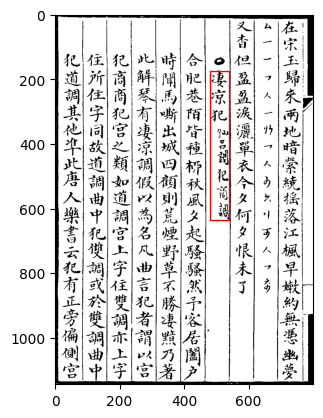

In [206]:
line_idx = 5
line_idx = 10
line_idx = 15
line_idx = 18
line_idx = 19
line_idx = 26
line_idx = 32

print(len(book.suspicious_lines))
print(book.suspicious_lines)
plt.figure()
line = book.suspicious_lines[line_idx]
print(line.page())
plt.imshow(Image.open(os.path.join(edition_directory, "images", line.page())), cmap="gray")
(x, y), (x2, y2) = line.coordinates()

rect = patches.Rectangle((x, y), x2-x, y2-y, linewidth=1, edgecolor='r', facecolor='none')
plt.gca().add_patch(rect)

<?xml version="1.0" encoding="UTF-8"?><?xml-model href="http://www.tei-c.org/release/xml/tei/custom/schema/relaxng/tei_all.rng" type="application/xml" schematypens="http://relaxng.org/ns/structure/1.0"?><?xml-model href="http://www.tei-c.org/release/xml/tei/custom/schema/relaxng/tei_all.rng" type="application/xml" schematypens="http://purl.oclc.org/dsdl/schematron"?><TEI xmlns="http://www.tei-c.org/ns/1.0"><teiHeader><fileDesc><titleStmt><title>Title</title></titleStmt><publicationStmt><p>Publication Information</p></publicationStmt><sourceDesc><p>Information about the source</p></sourceDesc></fileDesc></teiHeader><facsimile><surface xml:id="shanghai_manuscript_007"><graphic url="images/shanghai_manuscript_007.png"/><zone ulx="722" uly="17" lrx="783" lry="473" xml:id="line_0001"/><zone ulx="648" uly="64" lrx="706" lry="544" xml:id="line_0002"/><zone ulx="565" uly="121" lrx="627" lry="1129" xml:id="line_0003"/><zone ulx="488" uly="123" lrx="553" lry="1134" xml:id="line_0004"/><zone ulx=

In [172]:
def transform_juan_to_tei(juan_path: str):
    tei_string = ""
    all_jsons = sorted(os.listdir(juan_path))
    
    pieces = [json for json in all_jsons if json[0].isnumeric()]
    others = [json for json in all_jsons if not json[0].isnumeric()]
    
    for other in others:
        tei_string += transform_juan_description_to_tei(os.path.join(juan, other))
            
    for piece in pieces:
        tei_string += transform_piece_to_tei(os.path.join(juan, piece))
            
    return f'<div type="juan">{tei_string}</div>'

In [ ]:
def transform_book_to_tei(juan_division: list[str], other: str):
    tei_string = ""
    
    # Table of Contents
    # Juan 1: 01_shengsongnaogeguchuiqushisishou, 02_qinquyishou
    tei_string 
    # Juan 2: 03_yuejiuge
    # Juan 3: 04_ling
    # Juan 4: 05_man
    # Juan 5: 06_ziduqu
    # Juan 6: 07_zizhiqu
    # Appendix: 08_bieji
        
    return f'<div type="book">{tei_string}</div>'
    #return f'<div type="book" style="writing-mode: vertical-rl">{tei_string}</div>'

In [208]:
base_directory = "./json"

all_files = []
for folder in sorted(next(os.walk(base_directory))[1]):
    everything = sorted(os.listdir(os.path.join(base_directory, folder)))
    everything = [os.path.join(base_directory, folder, e) for e in everything]
    pieces = [e for e in everything if e[0].isnumeric()]
    other = [e for e in everything if not e[0].isnumeric()]
    
    all_files += other
    all_files += pieces
    
print(all_files)


['./json/01_shengsongnaogeguchuiqushisishou/01_shangdiming.json', './json/01_shengsongnaogeguchuiqushisishou/02_hezhibiao.json', './json/01_shengsongnaogeguchuiqushisishou/03_huaihaizhuo.json', './json/01_shengsongnaogeguchuiqushisishou/04_yuanzhishang.json', './json/01_shengsongnaogeguchuiqushisishou/05_huangweichang.json', './json/01_shengsongnaogeguchuiqushisishou/06_shushansui.json', './json/01_shengsongnaogeguchuiqushisishou/07_shiyupei.json', './json/01_shengsongnaogeguchuiqushisishou/08_wangzhongshan.json', './json/01_shengsongnaogeguchuiqushisishou/09_dazairen.json', './json/01_shengsongnaogeguchuiqushisishou/10_ougegui.json', './json/01_shengsongnaogeguchuiqushisishou/11_fagongji.json', './json/01_shengsongnaogeguchuiqushisishou/12_dilinyong.json', './json/01_shengsongnaogeguchuiqushisishou/13_weisiye.json', './json/01_shengsongnaogeguchuiqushisishou/14_yanjingfu.json', './json/01_shengsongnaogeguchuiqushisishou/shengsongnaogeguchuiqushisishou.json', './json/02_qinquyishou/015